# Semana 14 — Double Q-learning y diseño de recompensas

**Modelos de Decisión en el Tiempo — Aprendizaje por refuerzo tabular**

En esta sesión estudiaremos dos ideas nuevas:

1. el **sesgo de maximización** de Q-learning y su corrección mediante **Double Q-learning**;
2. el **reward shaping basado en potenciales** para acelerar el aprendizaje sin cambiar el problema de decisión.

La programación seguirá la misma progresión de las semanas anteriores:

$$
\text{una transición}\longrightarrow\text{una actualización}\longrightarrow\text{un episodio}\longrightarrow\text{muchos episodios}.
$$

El código utiliza arreglos de NumPy, ciclos, condicionales y funciones sencillas. No se requieren clases, diccionarios, comprensiones ni funciones anónimas.

## Herramientas de la sesión

| Herramienta | Idea principal |
|---|---|
| Q-learning | Selecciona y evalúa usando la misma tabla, lo que puede producir sobreestimación |
| Double Q-learning | Separa la tabla que selecciona de la tabla que evalúa |
| Reward shaping | Añade una señal de progreso construida a partir de un potencial |
| Value Iteration | Proporciona un benchmark exacto cuando el modelo es conocido |

La diferencia central de Double Q-learning es:

$$
a^* = \arg\max_a Q_1(s',a),
\qquad
\text{pero la acción se evalúa con } Q_2(s',a^*).
$$

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

---

# Ejercicio 1 — Sesgo de maximización

## FinVerde S.A.S.

En el estado **A**, la empresa decide entre:

- acción 0: gestión interna, recompensa 0 y terminación;
- acción 1: tercerizar, recompensa 0 y transición al estado **B**.

En el estado **B** se elige una de diez agencias. Cada agencia produce una recompensa aleatoria:

$$
R\sim\mathcal N(-0.1,1).
$$

La acción óptima en A es la gestión interna, porque 0 es mayor que la media verdadera de tercerizar, que es -0.1.

## 1.1 Orden correcto de una actualización de Q-learning

Cuando se elige tercerizar, el episodio tiene **dos transiciones**:

1. de A hacia B, con recompensa 0;
2. de B al estado terminal, con la recompensa de la agencia.

La transición A→B debe actualizarse usando los valores que existían en B **antes** de observar la recompensa posterior. En el siguiente episodio, una estimación positiva producida por ruido puede elevar artificialmente el máximo de B.

In [3]:
numero_agencias = 10
alpha_finverde = 0.1

Q_A_demo = np.zeros(2)
Q_B_demo = np.zeros(numero_agencias)

np.random.seed(1)

# Episodio 1: se fuerza la accion tercerizar.
accion_A = 1

# Primera transicion: A hacia B, recompensa 0.
objetivo_A = np.max(Q_B_demo)
Q_A_demo[accion_A] = Q_A_demo[accion_A] + alpha_finverde * (
    objetivo_A - Q_A_demo[accion_A]
)

# Segunda transicion: B hacia terminal.
agencia = 0
recompensa_agencia = np.random.normal(-0.1, 1.0)
Q_B_demo[agencia] = Q_B_demo[agencia] + alpha_finverde * (
    recompensa_agencia - Q_B_demo[agencia]
)

print("Despues del episodio 1:")
print("Recompensa observada:", recompensa_agencia)
print("Q(A, tercerizar):", Q_A_demo[1])
print("Valores de las agencias:", Q_B_demo)

# Episodio 2: antes de observar una nueva agencia, A usa el maximo actual de B.
objetivo_A = np.max(Q_B_demo)
Q_A_demo[1] = Q_A_demo[1] + alpha_finverde * (
    objetivo_A - Q_A_demo[1]
)

print()
print("Al comenzar el episodio 2:")
print("Maximo usado desde B:", objetivo_A)
print("Nuevo Q(A, tercerizar):", Q_A_demo[1])
print("El valor puede quedar positivo aunque la media verdadera sea -0.1.")

Despues del episodio 1:
Recompensa observada: 1.5243453636632416
Q(A, tercerizar): 0.0
Valores de las agencias: [0.152 0.    0.    0.    0.    0.    0.    0.    0.    0.   ]

Al comenzar el episodio 2:
Maximo usado desde B: 0.15243453636632417
Nuevo Q(A, tercerizar): 0.015243453636632417
El valor puede quedar positivo aunque la media verdadera sea -0.1.


## 1.2 Una actualización de Double Q-learning

Double Q-learning usa dos tablas. Cada transición decide de manera independiente cuál tabla actualizar.

En la transición A→B, si se actualiza Q1:

1. Q1 selecciona la agencia que parece mejor;
2. Q2 evalúa esa agencia.

Después, la transición B→terminal realiza una segunda elección independiente de la tabla que será actualizada.

In [4]:
Q1_A_demo = np.zeros(2)
Q2_A_demo = np.zeros(2)
Q1_B_demo = np.zeros(numero_agencias)
Q2_B_demo = np.zeros(numero_agencias)

# Supongamos que episodios anteriores dejaron estimaciones distintas.
Q1_B_demo[2] = 0.40
Q2_B_demo[2] = -0.05

# Transicion A hacia B: se actualiza Q1.
mejor_agencia_segun_Q1 = 2
valor_evaluado_con_Q2 = Q2_B_demo[mejor_agencia_segun_Q1]

Q1_A_demo[1] = Q1_A_demo[1] + alpha_finverde * (
    valor_evaluado_con_Q2 - Q1_A_demo[1]
)

print("Q1 selecciona la agencia:", mejor_agencia_segun_Q1)
print("Q1 le asignaba el valor:", Q1_B_demo[mejor_agencia_segun_Q1])
print("Q2 la evalua con el valor:", valor_evaluado_con_Q2)
print("Q1(A, tercerizar) queda en:", Q1_A_demo[1])

# Transicion B hacia terminal: se ejecuta una agencia y se decide nuevamente
# cual tabla actualizar. Esta decision es independiente de la anterior.
agencia_ejecutada = 4
np.random.seed(3)
recompensa_agencia = np.random.normal(-0.1, 1.0)
Q2_B_demo[agencia_ejecutada] = Q2_B_demo[agencia_ejecutada] + alpha_finverde * (
    recompensa_agencia - Q2_B_demo[agencia_ejecutada]
)

print()
print("Agencia ejecutada en B:", agencia_ejecutada)
print("Recompensa terminal observada:", recompensa_agencia)
print("Q2 de esa agencia despues de la segunda actualizacion:", Q2_B_demo[agencia_ejecutada])

Q1 selecciona la agencia: 2
Q1 le asignaba el valor: 0.4
Q2 la evalua con el valor: -0.05
Q1(A, tercerizar) queda en: -0.005000000000000001

Agencia ejecutada en B: 4
Recompensa terminal observada: 1.6886284734303185
Q2 de esa agencia despues de la segunda actualizacion: 0.16886284734303186


## 1.3 Funciones sencillas para desempatar y explorar

`np.argmax` siempre devuelve la primera acción cuando existen empates. Para no favorecer artificialmente la acción 0, escogeremos al azar entre todas las acciones que tengan el mayor valor.

In [6]:
def elegir_maximo_aleatorio(valores, numero_acciones):
    mejor_valor = valores[0]

    for accion in range(1, numero_acciones):
        if valores[accion] > mejor_valor:
            mejor_valor = valores[accion]

    candidatas = np.zeros(numero_acciones, dtype=int)
    numero_candidatas = 0

    for accion in range(numero_acciones):
        if abs(valores[accion] - mejor_valor) < 0.000000000001:
            candidatas[numero_candidatas] = accion
            numero_candidatas = numero_candidatas + 1

    posicion = np.random.randint(numero_candidatas)
    accion_elegida = candidatas[posicion]

    return accion_elegida


def elegir_epsilon_greedy(valores, numero_acciones, epsilon):
    numero_aleatorio = np.random.random()

    if numero_aleatorio < epsilon:
        accion_elegida = np.random.randint(numero_acciones)
    else:
        accion_elegida = elegir_maximo_aleatorio(
            valores,
            numero_acciones
        )

    return accion_elegida

## 1.4 Entrenamiento completo

La función de Q-learning respeta el orden temporal:

1. actualiza A→B;
2. elige la agencia;
3. observa la recompensa;
4. actualiza B→terminal.

En Double Q-learning, cada una de esas dos transiciones decide independientemente cuál tabla actualizar.

In [7]:
def entrenar_q_learning_finverde(
    numero_episodios,
    alpha,
    epsilon,
    semilla
):
    np.random.seed(semilla)

    Q_A = np.zeros(2)
    Q_B = np.zeros(numero_agencias)

    porcentaje_interna = np.zeros(numero_episodios)
    maximo_Q_A = np.zeros(numero_episodios)
    veces_interna = 0

    for episodio in range(numero_episodios):
        accion_A = elegir_epsilon_greedy(Q_A, 2, epsilon)

        if accion_A == 0:
            veces_interna = veces_interna + 1

            objetivo = 0.0
            Q_A[0] = Q_A[0] + alpha * (
                objetivo - Q_A[0]
            )

        else:
            # Transicion A hacia B.
            objetivo_A = np.max(Q_B)
            Q_A[1] = Q_A[1] + alpha * (
                objetivo_A - Q_A[1]
            )

            # Transicion B hacia terminal.
            agencia = elegir_epsilon_greedy(
                Q_B,
                numero_agencias,
                epsilon
            )
            recompensa = np.random.normal(-0.1, 1.0)
            Q_B[agencia] = Q_B[agencia] + alpha * (
                recompensa - Q_B[agencia]
            )

        porcentaje_interna[episodio] = (
            veces_interna / (episodio + 1) * 100
        )
        maximo_Q_A[episodio] = np.max(Q_A)

    return Q_A, Q_B, porcentaje_interna, maximo_Q_A


def entrenar_double_q_finverde(
    numero_episodios,
    alpha,
    epsilon,
    semilla
):
    np.random.seed(semilla)

    Q1_A = np.zeros(2)
    Q2_A = np.zeros(2)
    Q1_B = np.zeros(numero_agencias)
    Q2_B = np.zeros(numero_agencias)

    porcentaje_interna = np.zeros(numero_episodios)
    maximo_Q_A = np.zeros(numero_episodios)
    veces_interna = 0

    for episodio in range(numero_episodios):
        valores_A = Q1_A + Q2_A
        accion_A = elegir_epsilon_greedy(
            valores_A,
            2,
            epsilon
        )

        if accion_A == 0:
            veces_interna = veces_interna + 1

            if np.random.random() < 0.5:
                Q1_A[0] = Q1_A[0] + alpha * (
                    0.0 - Q1_A[0]
                )
            else:
                Q2_A[0] = Q2_A[0] + alpha * (
                    0.0 - Q2_A[0]
                )

        else:
            # Primera transicion: A hacia B.
            if np.random.random() < 0.5:
                mejor_agencia = elegir_maximo_aleatorio(
                    Q1_B,
                    numero_agencias
                )
                objetivo_A = Q2_B[mejor_agencia]
                Q1_A[1] = Q1_A[1] + alpha * (
                    objetivo_A - Q1_A[1]
                )
            else:
                mejor_agencia = elegir_maximo_aleatorio(
                    Q2_B,
                    numero_agencias
                )
                objetivo_A = Q1_B[mejor_agencia]
                Q2_A[1] = Q2_A[1] + alpha * (
                    objetivo_A - Q2_A[1]
                )

            # Segunda transicion: B hacia terminal.
            valores_B = Q1_B + Q2_B
            agencia = elegir_epsilon_greedy(
                valores_B,
                numero_agencias,
                epsilon
            )
            recompensa = np.random.normal(-0.1, 1.0)

            if np.random.random() < 0.5:
                Q1_B[agencia] = Q1_B[agencia] + alpha * (
                    recompensa - Q1_B[agencia]
                )
            else:
                Q2_B[agencia] = Q2_B[agencia] + alpha * (
                    recompensa - Q2_B[agencia]
                )

        porcentaje_interna[episodio] = (
            veces_interna / (episodio + 1) * 100
        )

        valores_promedio_A = (Q1_A + Q2_A) / 2
        maximo_Q_A[episodio] = np.max(valores_promedio_A)

    return (
        Q1_A,
        Q2_A,
        Q1_B,
        Q2_B,
        porcentaje_interna,
        maximo_Q_A
    )

In [8]:
numero_episodios_finverde = 500

Q_A_ql, Q_B_ql, porcentaje_ql, maximo_ql = entrenar_q_learning_finverde(
    numero_episodios_finverde,
    0.1,
    0.1,
    42
)

Q1_A_dql, Q2_A_dql, Q1_B_dql, Q2_B_dql, porcentaje_dql, maximo_dql = entrenar_double_q_finverde(
    numero_episodios_finverde,
    0.1,
    0.1,
    42
)

print("Porcentaje final con Q-learning:", porcentaje_ql[-1])
print("Porcentaje final con Double Q-learning:", porcentaje_dql[-1])
print("Referencia bajo epsilon = 0.1: aproximadamente 95 por ciento")

Porcentaje final con Q-learning: 52.800000000000004
Porcentaje final con Double Q-learning: 94.39999999999999
Referencia bajo epsilon = 0.1: aproximadamente 95 por ciento


## 1.5 Comparación con varias semillas

Con $\varepsilon=0.1$
, incluso una política greedy perfecta ejecuta la acción óptima aproximadamente el 95 % de las veces:

$$
0.9 + 0.1\left(\frac12\right) = 0.95.
$$

Usaremos 20 semillas para que el cuaderno pueda ejecutarse en clase. Treinta o más semillas pueden utilizarse como extensión.

In [9]:
numero_semillas_finverde = 20

porcentajes_ql = np.zeros(
    (numero_semillas_finverde, numero_episodios_finverde)
)
porcentajes_dql = np.zeros(
    (numero_semillas_finverde, numero_episodios_finverde)
)
maximos_ql = np.zeros(
    (numero_semillas_finverde, numero_episodios_finverde)
)
maximos_dql = np.zeros(
    (numero_semillas_finverde, numero_episodios_finverde)
)

for semilla in range(numero_semillas_finverde):
    Q_A, Q_B, porcentaje, maximo = entrenar_q_learning_finverde(
        numero_episodios_finverde,
        0.1,
        0.1,
        semilla
    )
    porcentajes_ql[semilla, :] = porcentaje
    maximos_ql[semilla, :] = maximo

    Q1_A, Q2_A, Q1_B, Q2_B, porcentaje, maximo = entrenar_double_q_finverde(
        numero_episodios_finverde,
        0.1,
        0.1,
        semilla
    )
    porcentajes_dql[semilla, :] = porcentaje
    maximos_dql[semilla, :] = maximo

media_porcentaje_ql = np.zeros(numero_episodios_finverde)
media_porcentaje_dql = np.zeros(numero_episodios_finverde)
media_maximo_ql = np.zeros(numero_episodios_finverde)
media_maximo_dql = np.zeros(numero_episodios_finverde)

for episodio in range(numero_episodios_finverde):
    suma_ql = 0.0
    suma_dql = 0.0
    suma_max_ql = 0.0
    suma_max_dql = 0.0

    for semilla in range(numero_semillas_finverde):
        suma_ql = suma_ql + porcentajes_ql[semilla, episodio]
        suma_dql = suma_dql + porcentajes_dql[semilla, episodio]
        suma_max_ql = suma_max_ql + maximos_ql[semilla, episodio]
        suma_max_dql = suma_max_dql + maximos_dql[semilla, episodio]

    media_porcentaje_ql[episodio] = suma_ql / numero_semillas_finverde
    media_porcentaje_dql[episodio] = suma_dql / numero_semillas_finverde
    media_maximo_ql[episodio] = suma_max_ql / numero_semillas_finverde
    media_maximo_dql[episodio] = suma_max_dql / numero_semillas_finverde

final_ql = porcentajes_ql[:, -1]
final_dql = porcentajes_dql[:, -1]

print("Promedio final de Q-learning:", np.mean(final_ql))
print("Desviacion entre semillas:", np.std(final_ql, ddof=1))
print()
print("Promedio final de Double Q-learning:", np.mean(final_dql))
print("Desviacion entre semillas:", np.std(final_dql, ddof=1))

Promedio final de Q-learning: 70.53999999999999
Desviacion entre semillas: 11.40269589545431

Promedio final de Double Q-learning: 88.9
Desviacion entre semillas: 6.944744321010711


### Visualización proporcionada

La siguiente celda solo representa las medias calculadas.

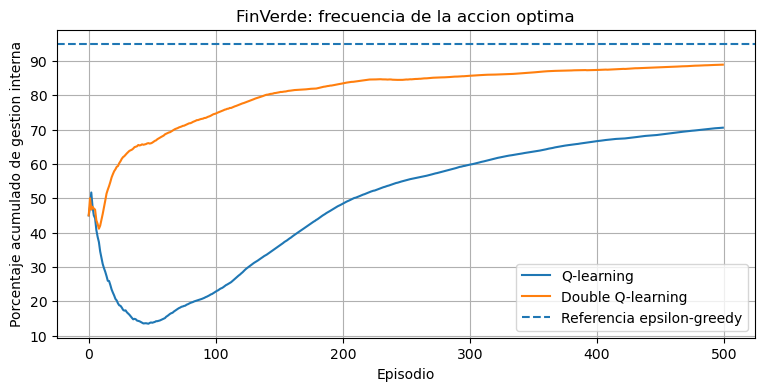

In [10]:
plt.figure(figsize=(9, 4))
plt.plot(media_porcentaje_ql, label="Q-learning")
plt.plot(media_porcentaje_dql, label="Double Q-learning")
plt.axhline(95, linestyle="--", label="Referencia epsilon-greedy")
plt.xlabel("Episodio")
plt.ylabel("Porcentaje acumulado de gestion interna")
plt.title("FinVerde: frecuencia de la accion optima")
plt.legend()
plt.grid()
plt.show()

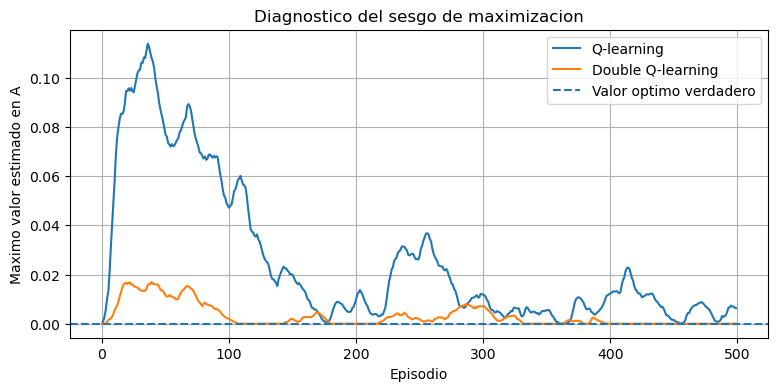

In [11]:
plt.figure(figsize=(9, 4))
plt.plot(media_maximo_ql, label="Q-learning")
plt.plot(media_maximo_dql, label="Double Q-learning")
plt.axhline(0, linestyle="--", label="Valor optimo verdadero")
plt.xlabel("Episodio")
plt.ylabel("Maximo valor estimado en A")
plt.title("Diagnostico del sesgo de maximizacion")
plt.legend()
plt.grid()
plt.show()

**Interpretación.** Double Q-learning reduce la sobreestimación porque la tabla que selecciona una acción no es la misma que la evalúa. En este experimento mejora la frecuencia de la acción óptima, pero no debe afirmarse que alcanza exactamente el 95 % en todas las ejecuciones finitas.

---

# Ejercicio 2 — Inventario con costo de faltante ruidoso

## DistiPacífico Ltda.

El inventario funciona de manera continua. Los bloques de 50 semanas son solamente segmentos de entrenamiento; no representan el final del sistema.

- Estado: inventario al inicio, de 0 a 6.
- Acción: unidades a ordenar, desde 0 hasta completar la capacidad.
- Demanda: Poisson con media 2.5, truncada en 6.
- Costo de faltante: uniforme entre 2 y 12.
- Descuento: (gamma=0.95).

Value Iteration puede usar la recompensa esperada. Como el costo de faltante entra linealmente y es independiente, se utiliza \(E[b]=7\).

## 2.1 Una transición manual

In [12]:
capacidad = 6
media_demanda = 2.5
precio_venta = 5.0
costo_orden = 2.0
costo_almacenamiento = 1.5
gamma_inventario = 0.95

np.random.seed(42)

estado = 3
accion = 1
inventario_disponible = estado + accion

demanda = np.random.poisson(media_demanda)
if demanda > capacidad:
    demanda = capacidad

vendido = min(inventario_disponible, demanda)
sobrante = max(0, inventario_disponible - demanda)
faltante = max(0, demanda - inventario_disponible)
costo_faltante = np.random.uniform(2, 12)

recompensa = (
    precio_venta * vendido
    - costo_orden * accion
    - costo_almacenamiento * sobrante
    - costo_faltante * faltante
)

print("Estado:", estado)
print("Accion:", accion)
print("Demanda:", demanda)
print("Costo aleatorio de faltante:", costo_faltante)
print("Estado siguiente:", sobrante)
print("Recompensa:", recompensa)

Estado: 3
Accion: 1
Demanda: 4
Costo aleatorio de faltante: 3.5599452033620267
Estado siguiente: 0
Recompensa: 18.0


## 2.2 Entorno y selección de acciones

In [13]:
def paso_inventario_ruidoso(estado, accion):
    inventario_disponible = estado + accion

    demanda = np.random.poisson(media_demanda)
    if demanda > capacidad:
        demanda = capacidad

    vendido = min(inventario_disponible, demanda)
    sobrante = max(0, inventario_disponible - demanda)
    faltante = max(0, demanda - inventario_disponible)
    costo_faltante = np.random.uniform(2, 12)

    recompensa = (
        precio_venta * vendido
        - costo_orden * accion
        - costo_almacenamiento * sobrante
        - costo_faltante * faltante
    )

    return sobrante, recompensa


def numero_acciones_validas_inventario(estado):
    numero_acciones = capacidad - estado + 1
    return numero_acciones


def politica_greedy_inventario(Q):
    politica = np.zeros(capacidad + 1, dtype=int)

    for estado in range(capacidad + 1):
        numero_acciones = numero_acciones_validas_inventario(estado)
        politica[estado] = elegir_maximo_aleatorio(
            Q[estado, :],
            numero_acciones
        )

    return politica


def politica_greedy_double_inventario(Q1, Q2):
    politica = np.zeros(capacidad + 1, dtype=int)

    for estado in range(capacidad + 1):
        numero_acciones = numero_acciones_validas_inventario(estado)
        valores = np.zeros(numero_acciones)

        for accion in range(numero_acciones):
            valores[accion] = Q1[estado, accion] + Q2[estado, accion]

        politica[estado] = elegir_maximo_aleatorio(
            valores,
            numero_acciones
        )

    return politica

## 2.3 SARSA, Q-learning y Double Q-learning

Las tres funciones usan matrices \(Q[estado,accion]\). No se utilizan diccionarios ni funciones anónimas.

In [14]:
def entrenar_sarsa_inventario(
    numero_episodios,
    pasos_por_segmento,
    alpha,
    semilla
):
    np.random.seed(semilla)

    Q = np.zeros((capacidad + 1, capacidad + 1))
    retornos = np.zeros(numero_episodios)

    for episodio in range(numero_episodios):
        epsilon = 1.0 - episodio / numero_episodios
        if epsilon < 0.05:
            epsilon = 0.05

        estado = capacidad // 2
        numero_acciones = numero_acciones_validas_inventario(estado)
        accion = elegir_epsilon_greedy(
            Q[estado, :],
            numero_acciones,
            epsilon
        )

        retorno = 0.0
        descuento = 1.0

        for paso in range(pasos_por_segmento):
            estado_siguiente, recompensa = paso_inventario_ruidoso(
                estado,
                accion
            )

            numero_acciones_siguientes = numero_acciones_validas_inventario(
                estado_siguiente
            )
            accion_siguiente = elegir_epsilon_greedy(
                Q[estado_siguiente, :],
                numero_acciones_siguientes,
                epsilon
            )

            objetivo = recompensa + gamma_inventario * Q[
                estado_siguiente,
                accion_siguiente
            ]

            Q[estado, accion] = Q[estado, accion] + alpha * (
                objetivo - Q[estado, accion]
            )

            retorno = retorno + descuento * recompensa
            descuento = descuento * gamma_inventario

            estado = estado_siguiente
            accion = accion_siguiente

        retornos[episodio] = retorno

    return Q, retornos


def entrenar_q_learning_inventario(
    numero_episodios,
    pasos_por_segmento,
    alpha,
    semilla
):
    np.random.seed(semilla)

    Q = np.zeros((capacidad + 1, capacidad + 1))
    retornos = np.zeros(numero_episodios)

    for episodio in range(numero_episodios):
        epsilon = 1.0 - episodio / numero_episodios
        if epsilon < 0.05:
            epsilon = 0.05

        estado = capacidad // 2
        retorno = 0.0
        descuento = 1.0

        for paso in range(pasos_por_segmento):
            numero_acciones = numero_acciones_validas_inventario(estado)
            accion = elegir_epsilon_greedy(
                Q[estado, :],
                numero_acciones,
                epsilon
            )

            estado_siguiente, recompensa = paso_inventario_ruidoso(
                estado,
                accion
            )

            numero_acciones_siguientes = numero_acciones_validas_inventario(
                estado_siguiente
            )
            mejor_accion = elegir_maximo_aleatorio(
                Q[estado_siguiente, :],
                numero_acciones_siguientes
            )

            objetivo = recompensa + gamma_inventario * Q[
                estado_siguiente,
                mejor_accion
            ]

            Q[estado, accion] = Q[estado, accion] + alpha * (
                objetivo - Q[estado, accion]
            )

            retorno = retorno + descuento * recompensa
            descuento = descuento * gamma_inventario
            estado = estado_siguiente

        retornos[episodio] = retorno

    return Q, retornos


def entrenar_double_q_inventario(
    numero_episodios,
    pasos_por_segmento,
    alpha,
    semilla
):
    np.random.seed(semilla)

    Q1 = np.zeros((capacidad + 1, capacidad + 1))
    Q2 = np.zeros((capacidad + 1, capacidad + 1))
    retornos = np.zeros(numero_episodios)

    for episodio in range(numero_episodios):
        epsilon = 1.0 - episodio / numero_episodios
        if epsilon < 0.05:
            epsilon = 0.05

        estado = capacidad // 2
        retorno = 0.0
        descuento = 1.0

        for paso in range(pasos_por_segmento):
            numero_acciones = numero_acciones_validas_inventario(estado)
            valores = np.zeros(numero_acciones)

            for accion_posible in range(numero_acciones):
                valores[accion_posible] = (
                    Q1[estado, accion_posible]
                    + Q2[estado, accion_posible]
                )

            accion = elegir_epsilon_greedy(
                valores,
                numero_acciones,
                epsilon
            )

            estado_siguiente, recompensa = paso_inventario_ruidoso(
                estado,
                accion
            )

            numero_acciones_siguientes = numero_acciones_validas_inventario(
                estado_siguiente
            )

            if np.random.random() < 0.5:
                mejor_accion = elegir_maximo_aleatorio(
                    Q1[estado_siguiente, :],
                    numero_acciones_siguientes
                )
                objetivo = recompensa + gamma_inventario * Q2[
                    estado_siguiente,
                    mejor_accion
                ]
                Q1[estado, accion] = Q1[estado, accion] + alpha * (
                    objetivo - Q1[estado, accion]
                )
            else:
                mejor_accion = elegir_maximo_aleatorio(
                    Q2[estado_siguiente, :],
                    numero_acciones_siguientes
                )
                objetivo = recompensa + gamma_inventario * Q1[
                    estado_siguiente,
                    mejor_accion
                ]
                Q2[estado, accion] = Q2[estado, accion] + alpha * (
                    objetivo - Q2[estado, accion]
                )

            retorno = retorno + descuento * recompensa
            descuento = descuento * gamma_inventario
            estado = estado_siguiente

        retornos[episodio] = retorno

    return Q1, Q2, retornos

In [15]:
episodios_demostracion = 1500
pasos_segmento = 50

Q_sarsa, retornos_sarsa = entrenar_sarsa_inventario(
    episodios_demostracion,
    pasos_segmento,
    0.1,
    42
)
Q_ql, retornos_ql = entrenar_q_learning_inventario(
    episodios_demostracion,
    pasos_segmento,
    0.1,
    42
)
Q1_dql, Q2_dql, retornos_dql = entrenar_double_q_inventario(
    episodios_demostracion,
    pasos_segmento,
    0.1,
    42
)

politica_sarsa = politica_greedy_inventario(Q_sarsa)
politica_ql = politica_greedy_inventario(Q_ql)
politica_dql = politica_greedy_double_inventario(Q1_dql, Q2_dql)

print("Politica SARSA:", politica_sarsa)
print("Politica Q-learning:", politica_ql)
print("Politica Double Q-learning:", politica_dql)

Politica SARSA: [5 4 3 2 0 0 0]
Politica Q-learning: [4 3 1 1 0 0 0]
Politica Double Q-learning: [4 5 3 2 1 0 0]


## 2.4 Value Iteration como benchmark

Value Iteration puede trabajar con recompensas aleatorias cuando se conoce su valor esperado. Aquí se utiliza \(E[b]=7\).

In [16]:
def probabilidades_demanda_truncada():
    probabilidades = np.zeros(capacidad + 1)

    probabilidades[0] = math.exp(-media_demanda)

    for demanda in range(1, capacidad):
        probabilidades[demanda] = (
            probabilidades[demanda - 1]
            * media_demanda
            / demanda
        )

    suma_parcial = 0.0
    for demanda in range(capacidad):
        suma_parcial = suma_parcial + probabilidades[demanda]

    probabilidades[capacidad] = 1.0 - suma_parcial

    return probabilidades


def value_iteration_inventario(tolerancia):
    probabilidades = probabilidades_demanda_truncada()
    valores = np.zeros(capacidad + 1)

    while True:
        valores_nuevos = np.zeros(capacidad + 1)

        for estado in range(capacidad + 1):
            numero_acciones = numero_acciones_validas_inventario(estado)
            mejor_valor = -1000000000.0

            for accion in range(numero_acciones):
                inventario_disponible = estado + accion
                valor_accion = 0.0

                for demanda in range(capacidad + 1):
                    vendido = min(inventario_disponible, demanda)
                    sobrante = max(0, inventario_disponible - demanda)
                    faltante = max(0, demanda - inventario_disponible)

                    recompensa = (
                        precio_venta * vendido
                        - costo_orden * accion
                        - costo_almacenamiento * sobrante
                        - 7.0 * faltante
                    )

                    valor_accion = valor_accion + probabilidades[demanda] * (
                        recompensa
                        + gamma_inventario * valores[sobrante]
                    )

                if valor_accion > mejor_valor:
                    mejor_valor = valor_accion

            valores_nuevos[estado] = mejor_valor

        cambio = np.max(np.abs(valores_nuevos - valores))
        valores = valores_nuevos

        if cambio < tolerancia:
            break

    politica = np.zeros(capacidad + 1, dtype=int)

    for estado in range(capacidad + 1):
        numero_acciones = numero_acciones_validas_inventario(estado)
        mejor_valor = -1000000000.0
        mejor_accion = 0

        for accion in range(numero_acciones):
            inventario_disponible = estado + accion
            valor_accion = 0.0

            for demanda in range(capacidad + 1):
                vendido = min(inventario_disponible, demanda)
                sobrante = max(0, inventario_disponible - demanda)
                faltante = max(0, demanda - inventario_disponible)

                recompensa = (
                    precio_venta * vendido
                    - costo_orden * accion
                    - costo_almacenamiento * sobrante
                    - 7.0 * faltante
                )

                valor_accion = valor_accion + probabilidades[demanda] * (
                    recompensa
                    + gamma_inventario * valores[sobrante]
                )

            if valor_accion > mejor_valor:
                mejor_valor = valor_accion
                mejor_accion = accion

        politica[estado] = mejor_accion

    return valores, politica


valores_vi, politica_vi = value_iteration_inventario(0.000001)

print("Politica de Value Iteration:", politica_vi)
print("Valores optimos:", valores_vi)

Politica de Value Iteration: [4 3 2 1 0 0 0]
Valores optimos: [65.171 67.171 69.171 71.171 73.171 74.805 75.521]


## 2.5 Comparación de las políticas de una semilla

In [17]:
print("Estado | VI | SARSA | Q-learning | Double Q")

for estado in range(capacidad + 1):
    print(
        estado,
        politica_vi[estado],
        politica_sarsa[estado],
        politica_ql[estado],
        politica_dql[estado]
    )

Estado | VI | SARSA | Q-learning | Double Q
0 4 5 4 4
1 3 4 3 5
2 2 3 1 3
3 1 2 1 2
4 0 0 0 1
5 0 0 0 0
6 0 0 0 0


Una sola semilla no es suficiente para concluir qué algoritmo es mejor. A continuación se entrenan cinco semillas y se evalúan las políticas greedy sin exploración. Las mismas demandas y los mismos costos de faltante se utilizan para todos los métodos.

In [18]:
numero_semillas_inventario = 5
numero_episodios_inventario = 1000

curvas_sarsa = np.zeros(
    (numero_semillas_inventario, numero_episodios_inventario)
)
curvas_ql = np.zeros(
    (numero_semillas_inventario, numero_episodios_inventario)
)
curvas_dql = np.zeros(
    (numero_semillas_inventario, numero_episodios_inventario)
)

politicas_sarsa = np.zeros(
    (numero_semillas_inventario, capacidad + 1),
    dtype=int
)
politicas_ql = np.zeros(
    (numero_semillas_inventario, capacidad + 1),
    dtype=int
)
politicas_dql = np.zeros(
    (numero_semillas_inventario, capacidad + 1),
    dtype=int
)

for semilla in range(numero_semillas_inventario):
    Q, retornos = entrenar_sarsa_inventario(
        numero_episodios_inventario,
        pasos_segmento,
        0.1,
        semilla
    )
    curvas_sarsa[semilla, :] = retornos
    politicas_sarsa[semilla, :] = politica_greedy_inventario(Q)

    Q, retornos = entrenar_q_learning_inventario(
        numero_episodios_inventario,
        pasos_segmento,
        0.1,
        semilla
    )
    curvas_ql[semilla, :] = retornos
    politicas_ql[semilla, :] = politica_greedy_inventario(Q)

    Q1, Q2, retornos = entrenar_double_q_inventario(
        numero_episodios_inventario,
        pasos_segmento,
        0.1,
        semilla
    )
    curvas_dql[semilla, :] = retornos
    politicas_dql[semilla, :] = politica_greedy_double_inventario(Q1, Q2)

media_curva_sarsa = np.zeros(numero_episodios_inventario)
media_curva_ql = np.zeros(numero_episodios_inventario)
media_curva_dql = np.zeros(numero_episodios_inventario)

for episodio in range(numero_episodios_inventario):
    suma_sarsa = 0.0
    suma_ql = 0.0
    suma_dql = 0.0

    for semilla in range(numero_semillas_inventario):
        suma_sarsa = suma_sarsa + curvas_sarsa[semilla, episodio]
        suma_ql = suma_ql + curvas_ql[semilla, episodio]
        suma_dql = suma_dql + curvas_dql[semilla, episodio]

    media_curva_sarsa[episodio] = suma_sarsa / numero_semillas_inventario
    media_curva_ql[episodio] = suma_ql / numero_semillas_inventario
    media_curva_dql[episodio] = suma_dql / numero_semillas_inventario

print("Entrenamiento con varias semillas completado.")

Entrenamiento con varias semillas completado.


### Visualización proporcionada

Las curvas muestran retornos de entrenamiento, que incluyen el costo de la exploración. El desempeño final se evaluará aparte con políticas greedy.

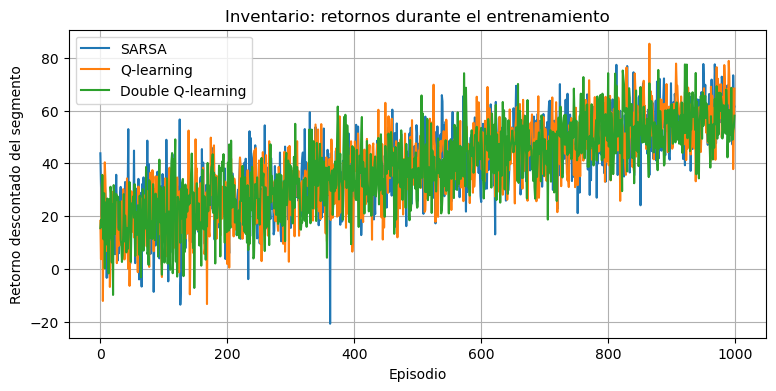

In [19]:
plt.figure(figsize=(9, 4))
plt.plot(media_curva_sarsa, label="SARSA")
plt.plot(media_curva_ql, label="Q-learning")
plt.plot(media_curva_dql, label="Double Q-learning")
plt.xlabel("Episodio")
plt.ylabel("Retorno descontado del segmento")
plt.title("Inventario: retornos durante el entrenamiento")
plt.legend()
plt.grid()
plt.show()

## 2.6 Evaluación greedy con escenarios comunes

In [20]:
numero_simulaciones_evaluacion = 500
pasos_evaluacion = 50

np.random.seed(8000)
demandas_evaluacion = np.zeros(
    (numero_simulaciones_evaluacion, pasos_evaluacion),
    dtype=int
)
costos_faltante_evaluacion = np.zeros(
    (numero_simulaciones_evaluacion, pasos_evaluacion)
)

for simulacion in range(numero_simulaciones_evaluacion):
    for paso in range(pasos_evaluacion):
        demanda = np.random.poisson(media_demanda)
        if demanda > capacidad:
            demanda = capacidad

        demandas_evaluacion[simulacion, paso] = demanda
        costos_faltante_evaluacion[simulacion, paso] = np.random.uniform(2, 12)


def evaluar_politica_inventario(
    politica,
    demandas,
    costos_faltante
):
    numero_simulaciones = demandas.shape[0]
    numero_pasos = demandas.shape[1]
    resultados = np.zeros(numero_simulaciones)

    for simulacion in range(numero_simulaciones):
        estado = capacidad // 2
        retorno = 0.0
        descuento = 1.0

        for paso in range(numero_pasos):
            accion = politica[estado]
            inventario_disponible = estado + accion
            demanda = demandas[simulacion, paso]
            costo_faltante = costos_faltante[simulacion, paso]

            vendido = min(inventario_disponible, demanda)
            sobrante = max(0, inventario_disponible - demanda)
            faltante = max(0, demanda - inventario_disponible)

            recompensa = (
                precio_venta * vendido
                - costo_orden * accion
                - costo_almacenamiento * sobrante
                - costo_faltante * faltante
            )

            retorno = retorno + descuento * recompensa
            descuento = descuento * gamma_inventario
            estado = sobrante

        resultados[simulacion] = retorno

    return resultados


resultados_vi = evaluar_politica_inventario(
    politica_vi,
    demandas_evaluacion,
    costos_faltante_evaluacion
)

medias_sarsa = np.zeros(numero_semillas_inventario)
medias_ql = np.zeros(numero_semillas_inventario)
medias_dql = np.zeros(numero_semillas_inventario)
diferencias_sarsa = np.zeros(numero_semillas_inventario)
diferencias_ql = np.zeros(numero_semillas_inventario)
diferencias_dql = np.zeros(numero_semillas_inventario)

for semilla in range(numero_semillas_inventario):
    resultados = evaluar_politica_inventario(
        politicas_sarsa[semilla, :],
        demandas_evaluacion,
        costos_faltante_evaluacion
    )
    medias_sarsa[semilla] = np.mean(resultados)
    diferencias_sarsa[semilla] = np.mean(resultados - resultados_vi)

    resultados = evaluar_politica_inventario(
        politicas_ql[semilla, :],
        demandas_evaluacion,
        costos_faltante_evaluacion
    )
    medias_ql[semilla] = np.mean(resultados)
    diferencias_ql[semilla] = np.mean(resultados - resultados_vi)

    resultados = evaluar_politica_inventario(
        politicas_dql[semilla, :],
        demandas_evaluacion,
        costos_faltante_evaluacion
    )
    medias_dql[semilla] = np.mean(resultados)
    diferencias_dql[semilla] = np.mean(resultados - resultados_vi)


def mostrar_resumen_evaluacion(nombre, medias, diferencias):
    media_general = np.mean(medias)
    error = 1.96 * np.std(medias, ddof=1) / math.sqrt(len(medias))

    diferencia_media = np.mean(diferencias)
    error_diferencia = 1.96 * np.std(diferencias, ddof=1) / math.sqrt(len(diferencias))

    print(nombre)
    print("Retorno medio:", media_general)
    print("Margen del IC entre semillas:", error)
    print("Diferencia media respecto de VI:", diferencia_media)
    print("Margen del IC de la diferencia:", error_diferencia)
    print()


print("Retorno de VI en los escenarios comunes:", np.mean(resultados_vi))
print()
mostrar_resumen_evaluacion("SARSA", medias_sarsa, diferencias_sarsa)
mostrar_resumen_evaluacion("Q-learning", medias_ql, diferencias_ql)
mostrar_resumen_evaluacion("Double Q-learning", medias_dql, diferencias_dql)

Retorno de VI en los escenarios comunes: 65.42422770016265

SARSA
Retorno medio: 62.868535708574676
Margen del IC entre semillas: 1.8688938917544136
Diferencia media respecto de VI: -2.5556919915879646
Margen del IC de la diferencia: 1.8688938917544131

Q-learning
Retorno medio: 61.82978122430622
Margen del IC entre semillas: 3.2252494842782595
Diferencia media respecto de VI: -3.5944464758564245
Margen del IC de la diferencia: 3.2252494842782577

Double Q-learning
Retorno medio: 54.75892945091614
Margen del IC entre semillas: 7.3290982020539674
Diferencia media respecto de VI: -10.665298249246511
Margen del IC de la diferencia: 7.329098202053969



**Interpretación.** Double Q-learning puede aprender más lentamente porque divide sus actualizaciones entre dos tablas. Por ello, comparar políticas finales requiere evaluación greedy y varias semillas; no basta con observar una sola tabla después del mismo número de episodios.

---

# Ejercicio 3 — Reward shaping basado en potenciales

## NaveCarga S.A.S.

El vehículo se desplaza en una grilla 5×5 desde (0,0) hasta (4,4). El objetivo es estudiar si una señal de progreso adicional facilita el aprendizaje.

- recompensa por paso: -1;
- recompensa al llegar: 20;
- potencial: distancia Manhattan negativa a la meta.

La recompensa no es completamente esparsa, porque existe una penalización en cada paso. Lo que llega tarde es la señal positiva de alcanzar la meta.

## 3.1 Una recompensa moldeada

In [21]:
filas = 5
columnas = 5
meta = (4, 4)
gamma_grid = 0.95
acciones_grid = [
    (-1, 0),
    (1, 0),
    (0, -1),
    (0, 1)
]


def potencial_grid(posicion):
    distancia_filas = abs(posicion[0] - meta[0])
    distancia_columnas = abs(posicion[1] - meta[1])
    potencial = -(distancia_filas + distancia_columnas)
    return potencial


estado = (0, 0)
accion = 3
nuevo_estado = (0, 1)
recompensa_original = -1.0

termino_shaping = (
    gamma_grid * potencial_grid(nuevo_estado)
    - potencial_grid(estado)
)
recompensa_moldeada = recompensa_original + termino_shaping

print("Estado actual:", estado)
print("Estado siguiente:", nuevo_estado)
print("Recompensa original:", recompensa_original)
print("Termino de shaping:", termino_shaping)
print("Recompensa moldeada:", recompensa_moldeada)

Estado actual: (0, 0)
Estado siguiente: (0, 1)
Recompensa original: -1.0
Termino de shaping: 1.3500000000000005
Recompensa moldeada: 0.35000000000000053


## 3.2 Entorno y Q-learning

In [22]:
def indice_grid(posicion):
    indice = posicion[0] * columnas + posicion[1]
    return indice


def paso_grid(posicion, accion):
    cambio_fila = acciones_grid[accion][0]
    cambio_columna = acciones_grid[accion][1]

    nueva_fila = posicion[0] + cambio_fila
    nueva_columna = posicion[1] + cambio_columna

    if nueva_fila < 0:
        nueva_fila = 0
    if nueva_fila >= filas:
        nueva_fila = filas - 1
    if nueva_columna < 0:
        nueva_columna = 0
    if nueva_columna >= columnas:
        nueva_columna = columnas - 1

    posicion_siguiente = (nueva_fila, nueva_columna)

    if posicion_siguiente == meta:
        recompensa = 20.0
        termino = True
    else:
        recompensa = -1.0
        termino = False

    return posicion_siguiente, recompensa, termino


def entrenar_q_learning_grid(
    numero_episodios,
    usar_shaping,
    semilla
):
    np.random.seed(semilla)

    numero_estados = filas * columnas
    numero_acciones = 4
    Q = np.zeros((numero_estados, numero_acciones))
    retornos = np.zeros(numero_episodios)

    for episodio in range(numero_episodios):
        epsilon = 1.0 - episodio / numero_episodios
        if epsilon < 0.05:
            epsilon = 0.05

        posicion = (0, 0)
        estado = indice_grid(posicion)
        retorno = 0.0
        descuento = 1.0

        for paso in range(100):
            accion = elegir_epsilon_greedy(
                Q[estado, :],
                numero_acciones,
                epsilon
            )

            posicion_siguiente, recompensa, termino = paso_grid(
                posicion,
                accion
            )
            estado_siguiente = indice_grid(posicion_siguiente)

            recompensa_utilizada = recompensa

            if usar_shaping:
                recompensa_utilizada = recompensa_utilizada + (
                    gamma_grid * potencial_grid(posicion_siguiente)
                    - potencial_grid(posicion)
                )

            if termino:
                objetivo = recompensa_utilizada
            else:
                mejor_accion = elegir_maximo_aleatorio(
                    Q[estado_siguiente, :],
                    numero_acciones
                )
                objetivo = recompensa_utilizada + gamma_grid * Q[
                    estado_siguiente,
                    mejor_accion
                ]

            Q[estado, accion] = Q[estado, accion] + 0.2 * (
                objetivo - Q[estado, accion]
            )

            retorno = retorno + descuento * recompensa
            descuento = descuento * gamma_grid

            posicion = posicion_siguiente
            estado = estado_siguiente

            if termino:
                break

        retornos[episodio] = retorno

    return Q, retornos

## 3.3 Una semilla y rutas greedy

No se compararán las políticas acción por acción, porque pueden existir varias rutas óptimas. La verificación apropiada consiste en comprobar si ambas rutas greedy llegan a la meta en ocho pasos, la distancia mínima desde (0,0).

In [23]:
def seguir_politica_grid(Q):
    np.random.seed(999)

    posicion = (0, 0)
    ruta = [posicion]
    llego = False

    for paso in range(30):
        estado = indice_grid(posicion)
        accion = elegir_maximo_aleatorio(Q[estado, :], 4)
        posicion_siguiente, recompensa, termino = paso_grid(
            posicion,
            accion
        )

        ruta.append(posicion_siguiente)
        posicion = posicion_siguiente

        if termino:
            llego = True
            break

    return ruta, llego


Q_sin_shaping, retornos_sin_shaping = entrenar_q_learning_grid(
    500,
    False,
    42
)
Q_con_shaping, retornos_con_shaping = entrenar_q_learning_grid(
    500,
    True,
    42
)

ruta_sin, llego_sin = seguir_politica_grid(Q_sin_shaping)
ruta_con, llego_con = seguir_politica_grid(Q_con_shaping)

print("Ruta sin shaping:", ruta_sin)
print("Numero de pasos:", len(ruta_sin) - 1)
print("Llego a la meta:", llego_sin)
print()
print("Ruta con shaping:", ruta_con)
print("Numero de pasos:", len(ruta_con) - 1)
print("Llego a la meta:", llego_con)

Ruta sin shaping: [(0, 0), (1, 0), (2, 0), (2, 1), (3, 1), (4, 1), (4, 2), (4, 3), (4, 4)]
Numero de pasos: 8
Llego a la meta: True

Ruta con shaping: [(0, 0), (1, 0), (1, 1), (2, 1), (2, 2), (2, 3), (3, 3), (4, 3), (4, 4)]
Numero de pasos: 8
Llego a la meta: True


## 3.4 Comparación con varias semillas

Se usan diez semillas y 500 episodios. Como indicador de aceleración se comparan los retornos medios durante los primeros y los últimos 100 episodios. No se denominará “convergencia” al cruce de un umbral arbitrario.

In [24]:
numero_semillas_grid = 10
numero_episodios_grid = 500

curvas_sin_shaping = np.zeros(
    (numero_semillas_grid, numero_episodios_grid)
)
curvas_con_shaping = np.zeros(
    (numero_semillas_grid, numero_episodios_grid)
)
pasos_ruta_sin = np.zeros(numero_semillas_grid)
pasos_ruta_con = np.zeros(numero_semillas_grid)

for semilla in range(numero_semillas_grid):
    Q, retornos = entrenar_q_learning_grid(
        numero_episodios_grid,
        False,
        semilla
    )
    curvas_sin_shaping[semilla, :] = retornos
    ruta, llego = seguir_politica_grid(Q)

    if llego:
        pasos_ruta_sin[semilla] = len(ruta) - 1
    else:
        pasos_ruta_sin[semilla] = 30

    Q, retornos = entrenar_q_learning_grid(
        numero_episodios_grid,
        True,
        semilla
    )
    curvas_con_shaping[semilla, :] = retornos
    ruta, llego = seguir_politica_grid(Q)

    if llego:
        pasos_ruta_con[semilla] = len(ruta) - 1
    else:
        pasos_ruta_con[semilla] = 30

media_sin_shaping = np.zeros(numero_episodios_grid)
media_con_shaping = np.zeros(numero_episodios_grid)

for episodio in range(numero_episodios_grid):
    suma_sin = 0.0
    suma_con = 0.0

    for semilla in range(numero_semillas_grid):
        suma_sin = suma_sin + curvas_sin_shaping[semilla, episodio]
        suma_con = suma_con + curvas_con_shaping[semilla, episodio]

    media_sin_shaping[episodio] = suma_sin / numero_semillas_grid
    media_con_shaping[episodio] = suma_con / numero_semillas_grid

print("Pasos greedy medios sin shaping:", np.mean(pasos_ruta_sin))
print("Pasos greedy medios con shaping:", np.mean(pasos_ruta_con))
print()
print("Retorno medio inicial sin shaping:", np.mean(curvas_sin_shaping[:, 0:100]))
print("Retorno medio inicial con shaping:", np.mean(curvas_con_shaping[:, 0:100]))
print()
print("Retorno medio final sin shaping:", np.mean(curvas_sin_shaping[:, -100:]))
print("Retorno medio final con shaping:", np.mean(curvas_con_shaping[:, -100:]))

Pasos greedy medios sin shaping: 8.0
Pasos greedy medios con shaping: 8.0

Retorno medio inicial sin shaping: -12.937115551573969
Retorno medio inicial con shaping: -13.036156845996196

Retorno medio final sin shaping: 6.712478455262284
Retorno medio final con shaping: 6.703985961790782


**Resultado del experimento.** En esta grilla pequeña, ambos métodos aprenden rutas mínimas y el shaping no produce una mejora clara en los retornos iniciales. Esto no contradice el teorema: el shaping basado en potenciales preserva las políticas óptimas, pero no garantiza una aceleración importante para toda elección de entorno, potencial e hiperparámetros.

### Visualización proporcionada

La gráfica muestra la media por episodio. No se evalúa la sintaxis de Matplotlib.

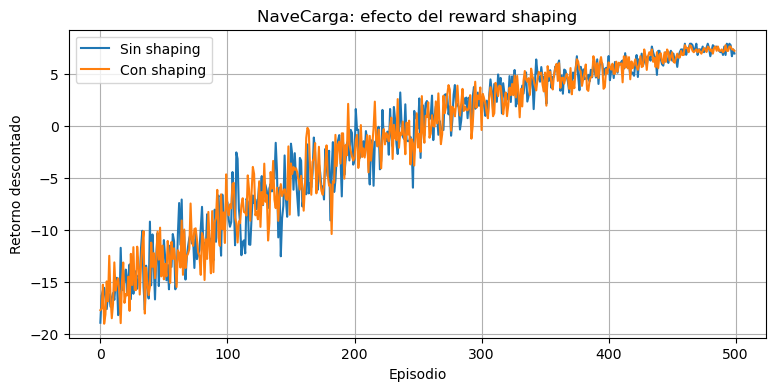

In [25]:
plt.figure(figsize=(9, 4))
plt.plot(media_sin_shaping, label="Sin shaping")
plt.plot(media_con_shaping, label="Con shaping")
plt.xlabel("Episodio")
plt.ylabel("Retorno descontado")
plt.title("NaveCarga: efecto del reward shaping")
plt.legend()
plt.grid()
plt.show()

**Preservación de la política.** El shaping basado en potenciales preserva el conjunto de políticas óptimas del MDP exacto. Dos entrenamientos finitos no tienen que seleccionar la misma flecha en todos los estados, especialmente cuando existen varias rutas óptimas. En este caso la comprobación relevante es que las rutas greedy alcancen la meta con la longitud mínima.

---

# Ejercicio abierto — Reemplazo de flota

## FlotAndes S.A.S.

El camión tiene seis niveles de desgaste:

\[
s\in\{0,1,2,3,4,5\},
\]

donde 0 representa un camión nuevo y 5 una **falla severa**.

Acciones:

- 0: operar;
- 1: mantenimiento menor;
- 2: reemplazar.

Al operar:

- aumenta un nivel con probabilidad 0.5;
- aumenta dos niveles con probabilidad 0.2;
- permanece igual con probabilidad 0.3.

La recompensa normal de operar es \(15-3s\). Si el estado siguiente es 5, ocurre una avería y la recompensa de esa transición es -40.

El sistema es continuo. Los bloques de 60 meses son segmentos de entrenamiento, no episodios terminales.

## Tareas organizadas por checkpoints

1. Calcule manualmente una transición de operar.
2. Implemente `paso_flota(estado, accion)` mediante una función sencilla.
3. Construya las probabilidades y recompensas esperadas para resolver Value Iteration.
4. Entrene SARSA y Q-learning.
5. Complete el esqueleto de Double Q-learning usando dos tablas.
6. Diseñe un potencial \(\Phi(s)\) y entrene Q-learning con shaping.
7. Compare las políticas greedy con el benchmark de VI.
8. Grafique curvas únicamente para los métodos que aprenden. VI debe aparecer como benchmark, no como curva de aprendizaje.
9. Use cinco o diez semillas en el laboratorio. Treinta semillas quedan como extensión.

## Verificación manual

In [24]:
estado = 2
accion = 0

recompensa_base = 15 - 3 * estado

np.random.seed(3)
numero_aleatorio = np.random.random()

if numero_aleatorio < 0.5:
    estado_siguiente = min(5, estado + 1)
elif numero_aleatorio < 0.7:
    estado_siguiente = min(5, estado + 2)
else:
    estado_siguiente = estado

if estado_siguiente == 5:
    recompensa_final = -40
    tipo_resultado = "averia"
else:
    recompensa_final = recompensa_base
    tipo_resultado = "operacion normal"

print("Estado actual:", estado)
print("Accion: operar")
print("Numero aleatorio:", numero_aleatorio)
print("Estado siguiente:", estado_siguiente)
print("Recompensa final:", recompensa_final)
print("Resultado:", tipo_resultado)

Estado actual: 2
Accion: operar
Numero aleatorio: 0.5507979025745755
Estado siguiente: 4
Recompensa final: 9
Resultado: operacion normal


## Orientación para el código

El código de la solución debe mantener el estilo de este cuaderno:

- matrices de NumPy para las tablas Q;
- ciclos y condicionales explícitos;
- ninguna clase;
- sin `defaultdict`, `lambda`, `zip`, `enumerate` o comprensiones;
- selección aleatoria en los empates;
- dos decisiones independientes sobre qué tabla actualizar en Double Q-learning;
- actualización con reward shaping:

\[
r'=r+\gamma\Phi(s')-\Phi(s).
\]

Double Q-learning puede implementarse a partir de dos matrices `Q1` y `Q2`. Cuando se actualice Q1, la mejor acción del estado siguiente se selecciona con Q1 y se evalúa con Q2; cuando se actualice Q2, se hace lo contrario.

In [25]:
# Escriba aqui la solucion del ejercicio abierto.
# Comience por la funcion paso_flota y verifique que reproduzca
# la transicion manual calculada en la celda anterior.


---

**Universidad de los Andes — Departamento de Ingeniería Industrial — Modelos de Decisión en el Tiempo — Semana 14**